The dataset is TITANIC and here are some key important things to note:
1. pclass has three classes: 1, 2, 3 where 1 = Upper, 2 = Middle, 3 = Lower
2. sibsp is the number of siblings and spouses on the ship
3. parch is the number of parents and children on the ship
4. fare is the fare paid for the ticket
5. embarked is the port of embarkation
6. survived is the target variable
    0 = No
    1 = Yes 


In [1]:
import pandas as pd

In [2]:
titanic = pd.read_csv("train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
titanic.shape

(891, 12)

In [6]:
titanic.Cabin.unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

## Hypothesis

1. Probability of survival is high if the person is female
2. Probability of survival is high if the person is child
3. Probability of survival is high if the person is rich 
4. Probability of survival is high if the person's cabin is away from at top deck like 'A'

## Sanity Checks

1. age below 0 and above 100 are invalid and are to be removed 
2. If survival rate is NAN then we should Remove them
3. If age is below 5 and Parch is 0 then we should check Ticket which might be shared with other family members that havent been reported in the dataset


## Extraction if Cabin 
We can group them with first letter like C185 be in C group and like that and find out which cabin had major survival rate and then we can decide which belonged to upper deck and which belonged to lower deck

In [7]:
titanic.Ticket.value_counts()

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64

In [8]:
titanic.loc[titanic['Ticket']=='347082']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.275,NaN,S
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.275,NaN,S
541,542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,347082,31.275,NaN,S
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.275,NaN,S
610,611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.275,NaN,S
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.275,NaN,S
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.275,NaN,S


In [9]:
titanic.loc[titanic['Ticket']=='1601']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
74,75,1,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,NaN,S
169,170,0,3,"Ling, Mr. Lee",male,28.0,0,0,1601,56.4958,NaN,S
509,510,1,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
643,644,1,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
692,693,1,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
826,827,0,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S


## Analysis of Ticket 

So in case of ticket analysis, we need found that the children and spouses all shared the same ticket.
And in case if the surname was different we could say that the children or spouses just had a old name or name based on their spouses but their parent or spouse bought the ticket for all.

So like in Real World it can be said like The father bought the ticket for their daughters who are married and their husband may also join.

We can also say that ticket number with different surnames can also end up with Friends and I think the same ticket number has same price so we can assume that its the price of the ticket per person.

## Figures 

For figure of Children and Females 
I would say bar chart can be used with X axis being Sex and Y axis being survived. As for Children I would say Using histograms would be better with X being Age and Y being Survived.

## Assumptions 

If lets say a group of 7 was boarded and like 6 died but 7th one survived it means we can assume the rest tried to save that person or that 7th tried to get a safe place and tried to rescue other but failed.

In [10]:
titanic['Group_Size'] = titanic.groupby(['Ticket'])['Ticket'].transform('count')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,2
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [11]:
titanic['Fare_per_person'] = titanic['Fare'] / titanic['Group_Size']
titanic.loc[titanic['Group_Size'] > 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,4,5.26875
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3,3.71110
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2,15.03540
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,2,8.35000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S,2,4.92290
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,2,41.57915
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,2,13.00000
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,5,5.82500


## Reasoning 

The reason why we chose Ticket over name is due to the fact that names are not unique and can be repeated hence someother people can be mapped secondly a group of people can be mapped to a single ticket cuz they all share same Ticket Number.

In [12]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.5500
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.0500


There is a conflict like Cumings, Mrs John Bradley (2) has paid more fare as compare to Futrelle, Mrs Jacques Heath (4) hence we can say Buying Ticket in Group cost less as compared to Buying a solo ticket

In [13]:
titanic['Group_Survival']= (titanic.groupby(['Ticket'])['Survived'].transform('sum') - titanic['Survived']) / (titanic['Group_Size'] - 1)
titanic.loc[titanic['Group_Size'] == 1, 'Group_Survival'] = -1
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,7.2500,-1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,71.2833,-1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.9250,-1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.5500,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.0500,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,13.0000,-1.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.0000,-1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,2,11.7250,0.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.0000,-1.0


In [14]:
titanic.loc[titanic['Group_Size'] > 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000,0.0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,4,5.26875,0.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3,3.71110,1.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2,15.03540,0.0
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,2,8.35000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S,2,4.92290,0.0
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,2,41.57915,1.0
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,2,13.00000,1.0
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,5,5.82500,0.0


In [15]:
titanic.loc[titanic['Ticket'] == '113803']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S,2,26.55,0.0
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.1,C123,S,2,26.55,1.0


In [16]:
titanic['Cabin'].isna().count()

np.int64(891)

In [17]:
titanic["Cabin"].fillna("U", inplace=True)

C:\Users\divya\AppData\Local\Temp\ipykernel_5800\422335106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Cabin"].fillna("U", inplace=True)


In [18]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,1,7.2500,-1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,71.2833,-1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1,7.9250,-1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.5500,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,1,8.0500,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,S,1,13.0000,-1.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.0000,-1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,U,S,2,11.7250,0.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.0000,-1.0


In [19]:
titanic['Deck'] = titanic['Cabin'].str[0]
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,1,7.2500,-1.0,U
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,71.2833,-1.0,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1,7.9250,-1.0,U
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.5500,0.0,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,1,8.0500,-1.0,U
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,S,1,13.0000,-1.0,U
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.0000,-1.0,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,U,S,2,11.7250,0.0,U
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.0000,-1.0,C


In [20]:
import seaborn as sns 
import matplotlib.pyplot as plt

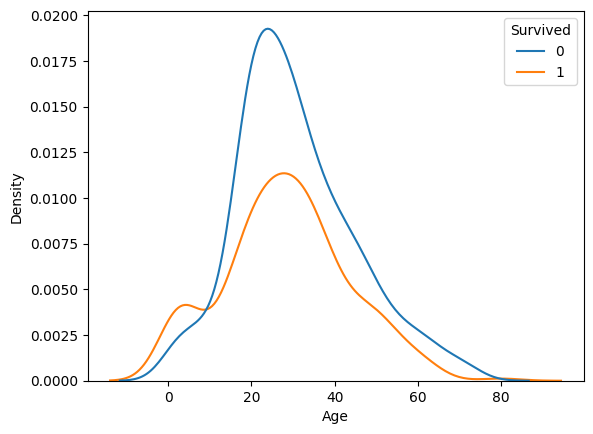

In [21]:
sns.kdeplot(data = titanic, x = 'Age', hue = 'Survived')
plt.show()

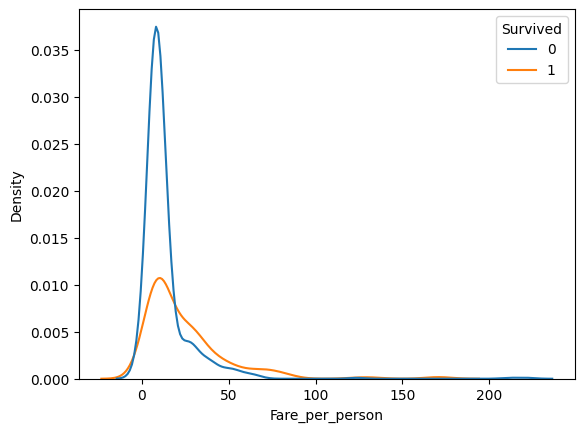

In [22]:
sns.kdeplot(data = titanic, x = 'Fare_per_person', hue = 'Survived')
plt.show()

The AGE KDE PLOT Shows one interesting hypothesis that children from age 0 - 10 survived more than adults which can lead that people tried to save children proving my 2nd Hypothesis. 

IN FARE_PER_PERSON KDE PLOT the people who payed more than 20 survived than those who paid less than 20 and this happened till 100. then around 125 and 175 people survived more.

<Axes: xlabel='Deck', ylabel='count'>

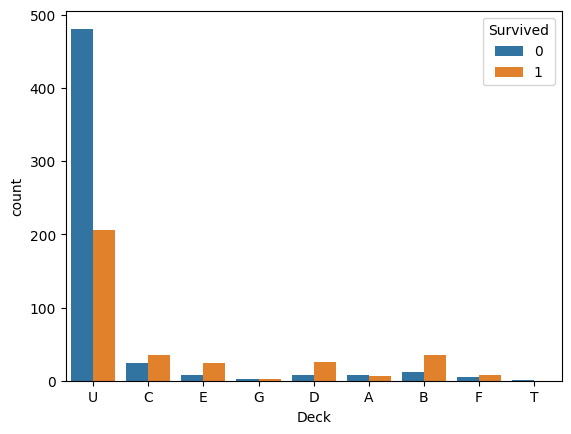

In [23]:
sns.countplot(data = titanic, x = 'Deck', hue = 'Survived')

In [24]:
titanic['Name'].unique()

array(['Braund, Mr. Owen Harris',
       'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
       'Heikkinen, Miss. Laina',
       'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
       'Allen, Mr. William Henry', 'Moran, Mr. James',
       'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard',
       'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
       'Nasser, Mrs. Nicholas (Adele Achem)',
       'Sandstrom, Miss. Marguerite Rut', 'Bonnell, Miss. Elizabeth',
       'Saundercock, Mr. William Henry', 'Andersson, Mr. Anders Johan',
       'Vestrom, Miss. Hulda Amanda Adolfina',
       'Hewlett, Mrs. (Mary D Kingcome) ', 'Rice, Master. Eugene',
       'Williams, Mr. Charles Eugene',
       'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)',
       'Masselmani, Mrs. Fatima', 'Fynney, Mr. Joseph J',
       'Beesley, Mr. Lawrence', 'McGowan, Miss. Anna "Annie"',
       'Sloper, Mr. William Thompson', 'Palsson, Miss. Torborg Danira',
       'Asplund, Mrs. Carl Oscar 

In [25]:
titanic['Title'] = titanic['Name'].str.extract(' ([A-Za-z]+)\.')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\divya\AppData\Local\Temp\ipykernel_5800\2528857505.py:1: SyntaxWarning: invalid escape sequence '\.'
  titanic['Title'] = titanic['Name'].str.extract(' ([A-Za-z]+)\.')


In [26]:
titanic['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [27]:
titanic.loc[~titanic['Title'].isin(['Master', 'Miss', 'Mr', 'Mrs']), 'Title'] = 'Rare'

In [28]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,1,7.2500,-1.0,U,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,71.2833,-1.0,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1,7.9250,-1.0,U,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.5500,0.0,C,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,1,8.0500,-1.0,U,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,S,1,13.0000,-1.0,U,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.0000,-1.0,B,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,U,S,2,11.7250,0.0,U,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.0000,-1.0,C,Mr


In [29]:
titanic['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

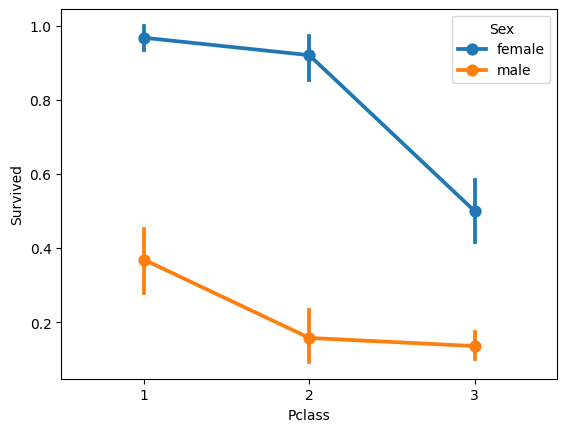

In [30]:
sns.pointplot(data = titanic, x = 'Pclass', y = 'Survived', hue = 'Sex')
plt.show()

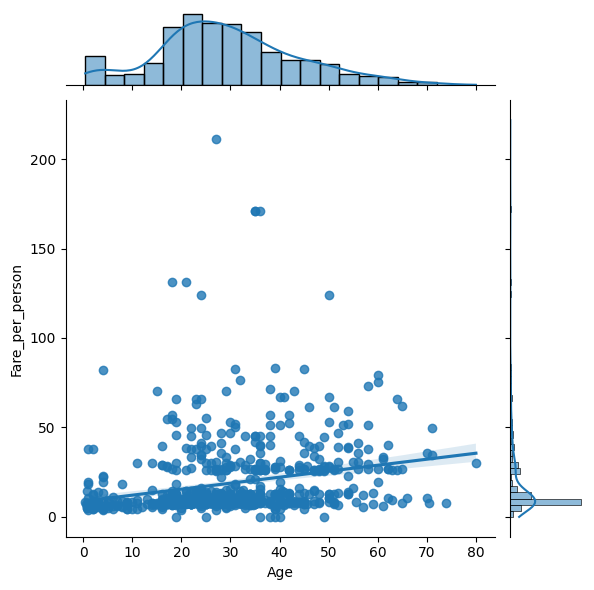

In [31]:
sns.jointplot(data = titanic, x = 'Age', y = 'Fare_per_person', kind = 'reg')
plt.show()

In [32]:
titanic.loc[titanic['Fare'] > 150]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival,Deck,Title
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S,4,65.750000,0.666667,C,Mr
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S,4,65.750000,0.333333,C,Miss
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,B58 B60,C,2,123.760400,1.000000,B,Mr
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,U,C,3,170.776400,1.000000,U,Miss
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.00,0,1,PC 17582,153.4625,C125,S,3,51.154167,0.500000,C,Mrs
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,4,37.887500,0.666667,C,Miss
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.00,0,1,PC 17558,247.5208,B58 B60,C,2,123.760400,0.000000,B,Mrs
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,4,37.887500,0.333333,C,Master
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.00,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,2,131.187500,1.000000,B,Miss
318,319,1,1,"Wick, Miss. Mary Natalie",female,31.00,0,2,36928,164.8667,C7,S,2,82.433350,1.000000,C,Miss


In [33]:
titanic.loc[titanic['Fare_per_person'] == 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival,Deck,Title
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,U,S,4,0.0,0.333333,U,Mr
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,1,0.0,-1.000000,B,Mr
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,U,S,4,0.0,0.000000,U,Mr
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,U,S,3,0.0,0.000000,U,Mr
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,U,S,4,0.0,0.333333,U,Mr
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,U,S,3,0.0,0.000000,U,Mr
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,U,S,3,0.0,0.000000,U,Mr
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,U,S,1,0.0,-1.000000,U,Mr
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,U,S,4,0.0,0.333333,U,Mr
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,U,S,1,0.0,-1.000000,U,Mr


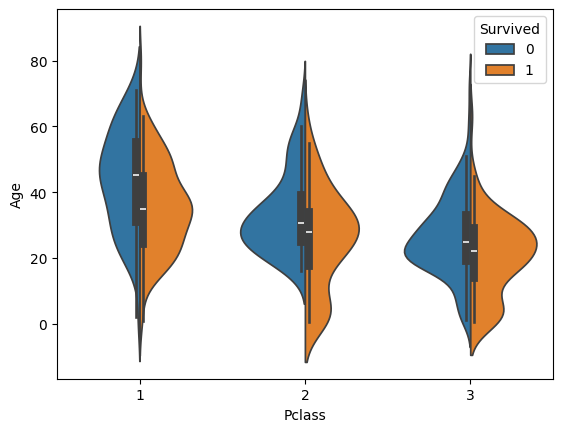

In [34]:
sns.violinplot(data = titanic, x = "Pclass", y = 'Age', hue = 'Survived', split = True)
plt.show()


In [35]:
titanic.loc[:, ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare_per_person', 'Group_Size', 'Group_Survival']].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare_per_person,Group_Size,Group_Survival
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.254824,0.038247,0.310641
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.655559,-0.002633,-0.296623
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.227631,-0.253507,-0.127231
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,-0.012298,0.661622,0.320035
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.060240,0.593076,0.400051
Fare_per_person,0.254824,-0.655559,0.227631,-0.012298,0.060240,1.000000,0.013853,0.231227
Group_Size,0.038247,-0.002633,-0.253507,0.661622,0.593076,0.013853,1.000000,0.604426
Group_Survival,0.310641,-0.296623,-0.127231,0.320035,0.400051,0.231227,0.604426,1.000000


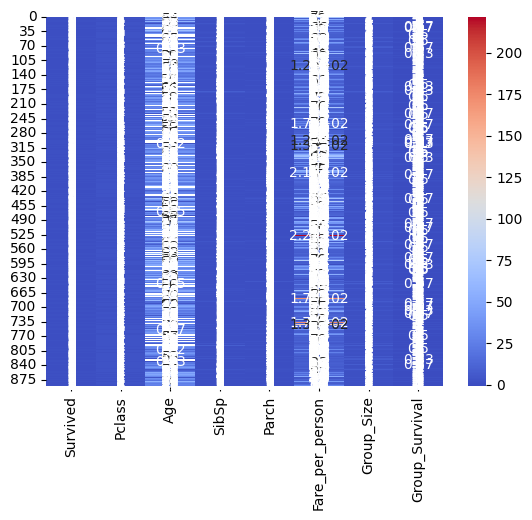

In [36]:
sns.heatmap(data = titanic.loc[:, ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare_per_person', 'Group_Size', 'Group_Survival']], annot = True, cmap = 'coolwarm')
plt.show()

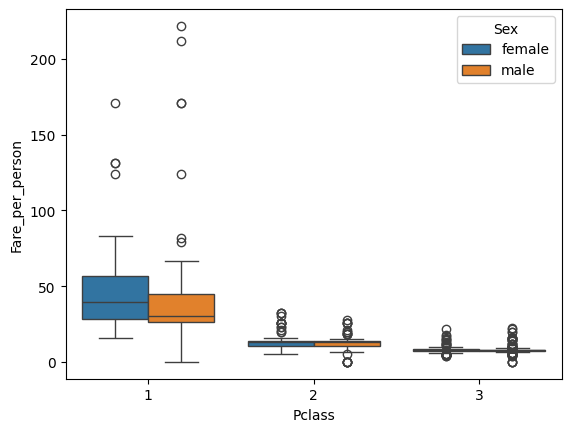

In [37]:
sns.boxplot(data=titanic, x='Pclass', y='Fare_per_person', hue='Sex')
plt.show()

In [38]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival,Deck,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,1,7.2500,-1.0,U,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,71.2833,-1.0,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,1,7.9250,-1.0,U,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.5500,0.0,C,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,1,8.0500,-1.0,U,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,S,1,13.0000,-1.0,U,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,30.0000,-1.0,B,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,U,S,2,11.7250,0.0,U,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,30.0000,-1.0,C,Mr


In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(titanic.drop(columns = ['Survived']), titanic['Survived'], test_size = 0.2, random_state = 42)
X_train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group_Size,Fare_per_person,Group_Survival,Deck,Title
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S,1,28.500000,-1.0,C,Mr
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,U,S,1,13.000000,-1.0,U,Mr
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,U,S,1,7.925000,-1.0,U,Mr
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,U,S,1,7.854200,-1.0,U,Mr
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,U,S,7,4.467857,0.0,U,Miss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,U,S,1,7.650000,-1.0,U,Miss
270,271,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,U,S,2,15.500000,1.0,U,Mr
860,861,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,U,S,1,14.108300,-1.0,U,Mr
435,436,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S,4,30.000000,1.0,B,Miss


In [40]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train[['Embarked']]), columns=ohe.get_feature_names_out(), index = X_train.index)
X_train_ohe

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
331,0.0,0.0,1.0,0.0
733,0.0,0.0,1.0,0.0
382,0.0,0.0,1.0,0.0
704,0.0,0.0,1.0,0.0
813,0.0,0.0,1.0,0.0
...,...,...,...,...
106,0.0,0.0,1.0,0.0
270,0.0,0.0,1.0,0.0
860,0.0,0.0,1.0,0.0
435,0.0,0.0,1.0,0.0


In [41]:
X_train_encoded = pd.concat([X_train.drop(columns = ['Embarked']), X_train_ohe], axis=1)
X_train_encoded

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Group_Size,Fare_per_person,Group_Survival,Deck,Title,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,1,28.500000,-1.0,C,Mr,0.0,0.0,1.0,0.0
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,U,1,13.000000,-1.0,U,Mr,0.0,0.0,1.0,0.0
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,U,1,7.925000,-1.0,U,Mr,0.0,0.0,1.0,0.0
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,U,1,7.854200,-1.0,U,Mr,0.0,0.0,1.0,0.0
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,U,7,4.467857,0.0,U,Miss,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,U,1,7.650000,-1.0,U,Miss,0.0,0.0,1.0,0.0
270,271,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,U,2,15.500000,1.0,U,Mr,0.0,0.0,1.0,0.0
860,861,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,U,1,14.108300,-1.0,U,Mr,0.0,0.0,1.0,0.0
435,436,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,4,30.000000,1.0,B,Miss,0.0,0.0,1.0,0.0


## Note

The above is OneHotEncoding but it add n columns for n values but it will add multicollinearity which we dont want hence we will drop 1 column

In [42]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop = 'first')
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train[['Embarked']]), columns=ohe.get_feature_names_out(), index = X_train.index)
X_train_ohe

,Embarked_Q,Embarked_S,Embarked_nan
331,0.0,1.0,0.0
733,0.0,1.0,0.0
382,0.0,1.0,0.0
704,0.0,1.0,0.0
813,0.0,1.0,0.0
...,...,...,...
106,0.0,1.0,0.0
270,0.0,1.0,0.0
860,0.0,1.0,0.0
435,0.0,1.0,0.0


In [43]:
X_train_encoded = pd.concat([X_train.drop(columns = ['Embarked']), X_train_ohe], axis=1)
X_train_encoded

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Group_Size,Fare_per_person,Group_Survival,Deck,Title,Embarked_Q,Embarked_S,Embarked_nan
331,332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,1,28.500000,-1.0,C,Mr,0.0,1.0,0.0
733,734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,U,1,13.000000,-1.0,U,Mr,0.0,1.0,0.0
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,U,1,7.925000,-1.0,U,Mr,0.0,1.0,0.0
704,705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,U,1,7.854200,-1.0,U,Mr,0.0,1.0,0.0
813,814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,U,7,4.467857,0.0,U,Miss,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,U,1,7.650000,-1.0,U,Miss,0.0,1.0,0.0
270,271,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,U,2,15.500000,1.0,U,Mr,0.0,1.0,0.0
860,861,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,U,1,14.108300,-1.0,U,Mr,0.0,1.0,0.0
435,436,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,4,30.000000,1.0,B,Miss,0.0,1.0,0.0
